# Dolphin Cup — clean baseline pipeline

Чистая версия текущего пайплайна: загрузка → EDA → group split → TF-IDF k-mers → One-vs-Rest SGD → calibration thresholds → честная проверка → диагностика → сохранение → submission.

**Важно:** для сравнения экспериментов ориентируемся на метрики на `check`, а не на метрики, на которых подбирались thresholds.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import gc
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score
from sklearn.linear_model import SGDClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    precision_recall_curve, precision_score, recall_score,
    f1_score, average_precision_score
)

In [11]:
RANDOM_STATE = 42
N_LABELS = 500
TARGET_COLUMNS = [f"label_{i}" for i in range(N_LABELS)]

# Поменяйте путь при необходимости (в Colab, например, на путь в Google Drive)
DATA_DIR = Path("./drive/MyDrive/datasets")

EXPERIMENT_NAME = "tfidf_4_5_sublinear_alpha1e6"
NGRAM_RANGE = (4, 5)
MIN_DF = 2
SUBLINEAR_TF = True
ALPHA = 1e-6
CLASS_WEIGHT = None

print("Experiment:", EXPERIMENT_NAME)

Experiment: tfidf_4_5_sublinear_alpha1e6


## 1. Load & sanity checks

In [12]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

required_train = {"protein_id", "sequence", *TARGET_COLUMNS}
required_test = {"protein_id", "sequence"}

assert required_train.issubset(train.columns)
assert required_test.issubset(test.columns)

print("train shape:", train.shape)
print("Number of target columns:", len(TARGET_COLUMNS))

missing = train[TARGET_COLUMNS].isna().sum()

print("Total NaN in targets:", missing.sum())
print("\nColumns with NaN:")
print(missing[missing > 0].sort_values(ascending=False).head(20))

bad_rows = train[TARGET_COLUMNS].isna().any(axis=1)

print("\nRows with NaN:", bad_rows.sum())

display(
    train.loc[
        bad_rows,
        ["protein_id", "sequence"] + TARGET_COLUMNS
    ].head()
)

# Проверяем targets
assert train[TARGET_COLUMNS].isna().sum().sum() == 0
assert train[TARGET_COLUMNS].isin([0, 1]).all().all()

# Более компактный dtype
train[TARGET_COLUMNS] = train[TARGET_COLUMNS].astype(np.uint8)

train = train.copy()
test = test.copy()

# Basic features
train["sequence_length"] = train["sequence"].str.len()
test["sequence_length"] = test["sequence"].str.len()

train["label_count"] = train[TARGET_COLUMNS].sum(axis=1)

print("Train:", train.shape)
print("Test:", test.shape)

print("Missing train sequence:", train["sequence"].isna().sum())
print("Missing test sequence:", test["sequence"].isna().sum())

print("Duplicate train sequences:", train["sequence"].duplicated().sum())
print("Duplicate test sequences:", test["sequence"].duplicated().sum())

display(
    train[["sequence_length", "label_count"]]
    .describe(percentiles=[.01, .25, .5, .75, .95, .99])
)

train shape: (113796, 502)
Number of target columns: 500
Total NaN in targets: 0

Columns with NaN:
Series([], dtype: int64)

Rows with NaN: 0


,protein_id,sequence,label_0,label_1,label_2,label_3,label_4,label_5,label_6,label_7,...,label_490,label_491,label_492,label_493,label_494,label_495,label_496,label_497,label_498,label_499


Train: (113796, 504)
Test: (28450, 3)
Missing train sequence: 0
Missing test sequence: 0
Duplicate train sequences: 3203
Duplicate test sequences: 119


,sequence_length,label_count
count,113796.000000,113796.000000
mean,553.188495,25.424145
std,643.483955,24.619158
min,3.000000,1.000000
1%,48.000000,3.000000
25%,247.000000,9.000000
50%,410.000000,17.000000
75%,652.000000,35.000000
95%,1434.000000,74.000000
99%,2725.000000,117.000000


## 2. Train / validation split
Одинаковые последовательности не могут оказаться одновременно в train и validation.

In [13]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, val_idx = next(splitter.split(train, groups=train["sequence"]))

train_part = train.iloc[train_idx].reset_index(drop=True)
validation_part = train.iloc[val_idx].reset_index(drop=True)

overlap = set(train_part["sequence"]) & set(validation_part["sequence"])
assert not overlap, f"Sequence leakage: {len(overlap)} overlaps"

print("Train part:", train_part.shape)
print("Validation part:", validation_part.shape)
print("Sequence overlap:", len(overlap))

Train part: (91057, 504)
Validation part: (22739, 504)
Sequence overlap: 0


## 3. TF-IDF k-mer features

In [14]:
vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=NGRAM_RANGE,
    lowercase=False,
    min_df=MIN_DF,
    sublinear_tf=SUBLINEAR_TF,
    dtype=np.float32,
)

X_train = vectorizer.fit_transform(train_part["sequence"])
X_validation = vectorizer.transform(validation_part["sequence"])
Y_train = train_part[TARGET_COLUMNS].to_numpy(dtype=np.uint8)
Y_validation = validation_part[TARGET_COLUMNS].to_numpy(dtype=np.uint8)

print("X_train:", X_train.shape, "nnz:", X_train.nnz)
print("X_validation:", X_validation.shape)
print("Y_train:", Y_train.shape, "Y_validation:", Y_validation.shape)
print("Vocabulary:", len(vectorizer.vocabulary_))

X_train: (91057, 2851227) nnz: 97552848
X_validation: (22739, 2851227)
Y_train: (91057, 500) Y_validation: (22739, 500)
Vocabulary: 2851227


## 4. Train 500 binary classifiers (One-vs-Rest)

In [15]:
base_model = SGDClassifier(
    loss="log_loss",
    alpha=ALPHA,
    class_weight=CLASS_WEIGHT,
    penalty="l2",
    max_iter=50,
    tol=1e-3,
    random_state=RANDOM_STATE,
)

multi_model = OneVsRestClassifier(
    base_model,
    n_jobs=-1,
    verbose=10
  )
multi_model.fit(X_train, Y_train)

validation_probabilities = multi_model.predict_proba(X_validation).astype(np.float32)
print("Probabilities:", validation_probabilities.shape)
print("Range:", validation_probabilities.min(), validation_probabilities.max())

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   24.9s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:  3.1min
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:  5.0min
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:  6.5min
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:  8.8min
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed: 11.0min
[Parallel(n_jobs=-1)]: Done  57 tasks      | elapsed: 13.9min
[Parallel(n_jobs=-1)]: Done  68 tasks      | elapsed: 16.4min
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed: 19.5min
[Parallel(n_jobs=-1)]: Done  94 tasks      | elapsed: 22.5min
[Parallel(n_jobs=-1)]: Done 109 tasks      | elapsed: 25.9min
[Parallel(n_jobs=-1)]: Done 124 tasks      | elapsed: 29.2min
[Parallel(n_jobs=-1)]: Done 141 tasks      | elapsed: 32

Probabilities: (22739, 500)
Range: 0.00010556343 0.99793965


In [9]:
# ============================================================
# FAST N-GRAM SEARCH
# Compare: (3,4), (3,5), (4,5)
# Metric: Macro Average Precision on the same 50 labels
# ============================================================

import gc
import time
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import average_precision_score


# ------------------------------------------------------------
# 1. Settings
# ------------------------------------------------------------

ALPHA_FAST = 1e-6
MIN_DF_FAST = 2
SUBLINEAR_FAST = True

N_FAST_LABELS = 50
RANDOM_STATE_FAST = 42

NGRAM_VARIANTS = [
    (3, 4),
    (3, 5),
    (4, 5),
]


# ------------------------------------------------------------
# 2. Restore Y matrices if necessary
# ------------------------------------------------------------

Y_train = train_part[TARGET_COLUMNS].to_numpy(
    dtype=np.uint8
)

Y_validation = validation_part[TARGET_COLUMNS].to_numpy(
    dtype=np.uint8
)

print("Y_train:", Y_train.shape)
print("Y_validation:", Y_validation.shape)

assert Y_train.shape[1] == 500
assert Y_validation.shape[1] == 500


# ------------------------------------------------------------
# 3. Choose SAME 50 representative labels
# ------------------------------------------------------------

label_counts = Y_train.sum(axis=0)

sorted_labels = np.argsort(label_counts)

positions = np.linspace(
    0,
    len(sorted_labels) - 1,
    N_FAST_LABELS
).astype(int)

fast_labels = sorted_labels[positions]

print("\nFast labels:", len(fast_labels))
print(
    "Positive range:",
    int(label_counts[fast_labels].min()),
    "->",
    int(label_counts[fast_labels].max())
)


# ------------------------------------------------------------
# 4. Run experiments
# ------------------------------------------------------------

results = []

for ngram_range in NGRAM_VARIANTS:

    print("\n")
    print("=" * 60)
    print("NGRAM:", ngram_range)
    print("=" * 60)

    start_time = time.time()

    # -----------------------------
    # TF-IDF
    # -----------------------------

    vectorizer_fast = TfidfVectorizer(
        analyzer="char",
        ngram_range=ngram_range,
        lowercase=False,
        min_df=MIN_DF_FAST,
        sublinear_tf=SUBLINEAR_FAST,
        dtype=np.float32
    )

    print("Building TF-IDF...")

    X_train_fast = vectorizer_fast.fit_transform(
        train_part["sequence"]
    )

    X_validation_fast = vectorizer_fast.transform(
        validation_part["sequence"]
    )

    vocabulary_size = len(
        vectorizer_fast.vocabulary_
    )

    train_nnz = X_train_fast.nnz

    print("X_train:", X_train_fast.shape)
    print("X_validation:", X_validation_fast.shape)
    print("Vocabulary:", f"{vocabulary_size:,}")
    print("Train nnz:", f"{train_nnz:,}")


    # -----------------------------
    # Train 50 classifiers
    # -----------------------------

    ap_scores = []

    print("\nTraining classifiers...")

    for i, label_idx in enumerate(fast_labels):

        model_fast = SGDClassifier(
            loss="log_loss",
            alpha=ALPHA_FAST,
            class_weight=None,
            penalty="l2",
            max_iter=50,
            tol=1e-3,
            random_state=RANDOM_STATE_FAST
        )

        y_train_label = Y_train[:, label_idx]
        y_val_label = Y_validation[:, label_idx]

        model_fast.fit(
            X_train_fast,
            y_train_label
        )

        probabilities = model_fast.predict_proba(
            X_validation_fast
        )[:, 1]

        ap = average_precision_score(
            y_val_label,
            probabilities
        )

        ap_scores.append(ap)

        if (i + 1) % 10 == 0:
            print(
                f"{i + 1:2d}/{N_FAST_LABELS}"
                f" | mean AP = {np.mean(ap_scores):.6f}"
            )


    # -----------------------------
    # Save result
    # -----------------------------

    macro_ap = float(
        np.mean(ap_scores)
    )

    elapsed = time.time() - start_time

    results.append({
        "ngram_range": str(ngram_range),
        "macro_ap": macro_ap,
        "vocabulary": vocabulary_size,
        "train_nnz": train_nnz,
        "time_min": elapsed / 60
    })

    print("\nMacro AP:", macro_ap)
    print(
        "Time:",
        round(elapsed / 60, 2),
        "min"
    )


    # -----------------------------
    # Free RAM
    # -----------------------------

    del X_train_fast
    del X_validation_fast
    del vectorizer_fast
    del model_fast
    del probabilities

    gc.collect()


# ------------------------------------------------------------
# 5. Final comparison
# ------------------------------------------------------------

ngram_results = pd.DataFrame(results)

ngram_results = ngram_results.sort_values(
    "macro_ap",
    ascending=False
).reset_index(drop=True)

baseline_ap = ngram_results.loc[
    ngram_results["ngram_range"] == "(3, 4)",
    "macro_ap"
].iloc[0]

ngram_results["delta_vs_3_4"] = (
    ngram_results["macro_ap"]
    - baseline_ap
)

print("\n")
print("=" * 60)
print("FINAL N-GRAM RESULTS")
print("=" * 60)

display(ngram_results)

Y_train: (91057, 500)
Y_validation: (22739, 500)

Fast labels: 50
Positive range: 1009 -> 59746


NGRAM: (3, 4)
Building TF-IDF...
X_train: (91057, 168894)
X_validation: (22739, 168894)
Vocabulary: 168,894
Train nnz: 91,573,289

Training classifiers...
10/50 | mean AP = 0.350327
20/50 | mean AP = 0.324323
30/50 | mean AP = 0.352228
40/50 | mean AP = 0.351122
50/50 | mean AP = 0.374225

Macro AP: 0.37422458062365416
Time: 6.88 min


NGRAM: (3, 5)
Building TF-IDF...
X_train: (91057, 2859839)
X_validation: (22739, 2859839)
Vocabulary: 2,859,839
Train nnz: 140,594,193

Training classifiers...
10/50 | mean AP = 0.360127
20/50 | mean AP = 0.334744
30/50 | mean AP = 0.364365
40/50 | mean AP = 0.365368
50/50 | mean AP = 0.394414

Macro AP: 0.39441387416293816
Time: 18.9 min


NGRAM: (4, 5)
Building TF-IDF...
X_train: (91057, 2851227)
X_validation: (22739, 2851227)
Vocabulary: 2,851,227
Train nnz: 97,552,848

Training classifiers...
10/50 | mean AP = 0.361936
20/50 | mean AP = 0.335656
30/50 | 

,ngram_range,macro_ap,vocabulary,train_nnz,time_min,delta_vs_3_4
0,"(4, 5)",0.394480,2851227,97552848,13.821831,0.020255
1,"(3, 5)",0.394414,2859839,140594193,18.904817,0.020189
2,"(3, 4)",0.374225,168894,91573289,6.875410,0.000000


## 5. Calibration / honest check
Validation делится пополам: на первой части выбираем threshold для каждой метки, на второй считаем итоговые метрики.

In [16]:
threshold_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.5,
    random_state=123
)

calibration_indices, check_indices = next(
    threshold_splitter.split(
        validation_part,
        groups=validation_part["sequence"]
    )
)

Y_calibration = Y_validation[calibration_indices]
P_calibration = validation_probabilities[calibration_indices]

Y_check = Y_validation[check_indices]
P_check = validation_probabilities[check_indices]

print("Calibration:", Y_calibration.shape)
print("Check:", Y_check.shape)


# ==========================================
# 2. Проверяем разные стратегии threshold
# ==========================================

MIN_POSITIVE_OPTIONS = [0, 5, 10, 20, 30, 50, 100]

results = []
all_thresholds = {}

for min_positives in MIN_POSITIVE_OPTIONS:

    thresholds_per_label = np.full(
        500,
        0.5,
        dtype=np.float32
    )

    for j in range(500):

        y_true = Y_calibration[:, j]
        y_prob = P_calibration[:, j]

        positives = y_true.sum()

        if positives < min_positives:
            continue

        precision, recall, thresholds = (
            precision_recall_curve(
                y_true,
                y_prob
            )
        )

        if len(thresholds) == 0:
            continue

        f1_values = (
            2 * precision[:-1] * recall[:-1]
            /
            (
                precision[:-1]
                + recall[:-1]
                + 1e-12
            )
        )

        best_position = np.argmax(f1_values)

        thresholds_per_label[j] = (
            thresholds[best_position]
        )

    # Проверяем thresholds на НЕВИДЕННОЙ check части

    predictions = (
        P_check >= thresholds_per_label
    ).astype(np.uint8)

    macro_f1 = f1_score(
        Y_check,
        predictions,
        average="macro",
        zero_division=0
    )

    micro_f1 = f1_score(
        Y_check,
        predictions,
        average="micro",
        zero_division=0
    )

    macro_precision = precision_score(
        Y_check,
        predictions,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        Y_check,
        predictions,
        average="macro",
        zero_division=0
    )

    results.append({
        "min_positives": min_positives,
        "macro_f1": macro_f1,
        "micro_f1": micro_f1,
        "precision": macro_precision,
        "recall": macro_recall,
        "pred_labels": predictions.sum(axis=1).mean(),
        "fallback_labels": int(
            (Y_calibration.sum(axis=0) < min_positives).sum()
        )
    })

    all_thresholds[min_positives] = thresholds_per_label


# ==========================================
# 3. Показываем результаты
# ==========================================

threshold_results = pd.DataFrame(results)

display(
    threshold_results.sort_values(
        "macro_f1",
        ascending=False
    )
)


# ==========================================
# 4. Сохраняем лучший вариант
# ==========================================

best_row = threshold_results.loc[
    threshold_results["macro_f1"].idxmax()
]

BEST_MIN_POSITIVES = int(
    best_row["min_positives"]
)

honest_thresholds = all_thresholds[
    BEST_MIN_POSITIVES
]

check_predictions = (
    P_check >= honest_thresholds
).astype(np.uint8)

honest_macro_f1 = float(
    best_row["macro_f1"]
)

print("\nBEST MIN POSITIVES:", BEST_MIN_POSITIVES)
print("Macro F1:", honest_macro_f1)
print("Micro F1:", best_row["micro_f1"])

print(
    "True labels/protein:",
    Y_check.sum(axis=1).mean()
)

print(
    "Pred labels/protein:",
    check_predictions.sum(axis=1).mean()
)

Calibration: (11353, 500)
Check: (11386, 500)


,min_positives,macro_f1,micro_f1,precision,recall,pred_labels,fallback_labels
0,0,0.393592,0.508813,0.436083,0.383432,28.443,0
1,5,0.393592,0.508813,0.436083,0.383432,28.443,0
2,10,0.393592,0.508813,0.436083,0.383432,28.443,0
3,20,0.393592,0.508813,0.436083,0.383432,28.443,0
4,30,0.393592,0.508813,0.436083,0.383432,28.443,0
5,50,0.393592,0.508813,0.436083,0.383432,28.443,0
6,100,0.393592,0.508813,0.436083,0.383432,28.443,0



BEST MIN POSITIVES: 0
Macro F1: 0.3935921826448447
Micro F1: 0.5088133362295066
True labels/protein: 25.73809942034077
Pred labels/protein: 28.443000175654312


## 6. Honest metrics

In [17]:
check_predictions = (
    P_check >= honest_thresholds
).astype(np.uint8)

active_labels = Y_check.sum(axis=0) > 0

f1_per_label = f1_score(
    Y_check,
    check_predictions,
    average=None,
    zero_division=0
)

metrics = {
    "experiment": EXPERIMENT_NAME,
    "macro_f1": float(f1_per_label[active_labels].mean()),
    "micro_f1": float(f1_score(Y_check, check_predictions, average="micro", zero_division=0)),
    "macro_precision": float(precision_score(Y_check, check_predictions, average="macro", zero_division=0)),
    "macro_recall": float(recall_score(Y_check, check_predictions, average="macro", zero_division=0)),
    "macro_ap": float(average_precision_score(Y_check, P_check, average="macro")),
    "true_labels_per_protein": float(Y_check.sum(axis=1).mean()),
    "pred_labels_per_protein": float(check_predictions.sum(axis=1).mean()),
}

display(pd.DataFrame(metrics.items(), columns=["metric", "value"]))

,metric,value
0,experiment,tfidf_4_5_sublinear_alpha1e6
1,macro_f1,0.393592
2,micro_f1,0.508813
3,macro_precision,0.436083
4,macro_recall,0.383432
5,macro_ap,0.381978
6,true_labels_per_protein,25.738099
7,pred_labels_per_protein,28.443


## global threshold scan

In [19]:
threshold_grid = np.arange(0.05, 0.81, 0.025)

rows = []

for threshold in threshold_grid:
    predictions = (
        validation_probabilities >= threshold
    ).astype(np.uint8)

    macro_f1 = f1_score(
        Y_validation,
        predictions,
        average="macro",
        zero_division=0
    )

    micro_f1 = f1_score(
        Y_validation,
        predictions,
        average="micro",
        zero_division=0
    )

    pred_per_protein = predictions.sum(axis=1).mean()

    rows.append({
        "threshold": threshold,
        "macro_f1": macro_f1,
        "micro_f1": micro_f1,
        "pred_labels_per_protein": pred_per_protein
    })

threshold_results = pd.DataFrame(rows)

display(
    threshold_results
    .sort_values("macro_f1", ascending=False)
    .head(15)
)

,threshold,macro_f1,micro_f1,pred_labels_per_protein
2,0.100,0.388666,0.502181,35.871542
3,0.125,0.388426,0.512625,31.556401
4,0.150,0.386504,0.518114,28.459695
1,0.075,0.384996,0.482007,42.693082
5,0.175,0.383558,0.520606,26.062008
6,0.200,0.380406,0.521090,24.105941
7,0.225,0.376258,0.519762,22.446018
8,0.250,0.372054,0.517874,20.994239
0,0.050,0.371076,0.440566,55.894454
9,0.275,0.367712,0.515002,19.715335


In [20]:
best_row = threshold_results.loc[
    threshold_results["macro_f1"].idxmax()
]

BEST_GLOBAL_THRESHOLD = float(best_row["threshold"])

print("Best global threshold:", BEST_GLOBAL_THRESHOLD)
print("Best macro F1:", best_row["macro_f1"])
print("Micro F1:", best_row["micro_f1"])
print(
    "Pred labels/protein:",
    best_row["pred_labels_per_protein"]
)
print(
    "True labels/protein:",
    Y_validation.sum(axis=1).mean()
)

Best global threshold: 0.10000000000000002
Best macro F1: 0.3886662110953188
Micro F1: 0.5021807754058903
Pred labels/protein: 35.87154228418136
True labels/protein: 25.59413342715159


## 7. Diagnostics

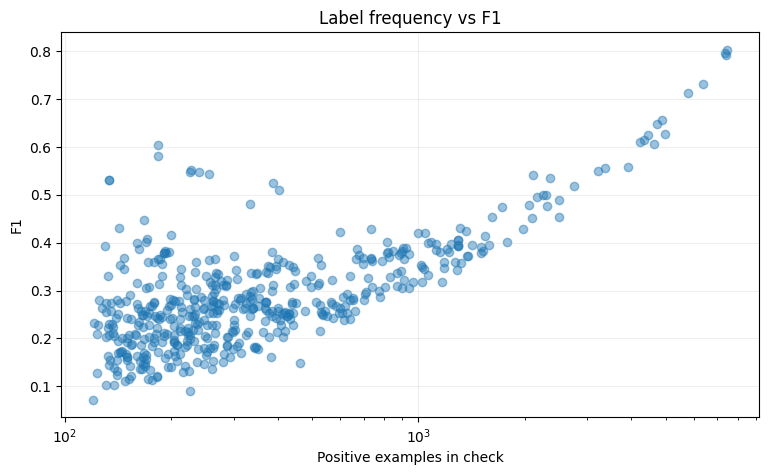

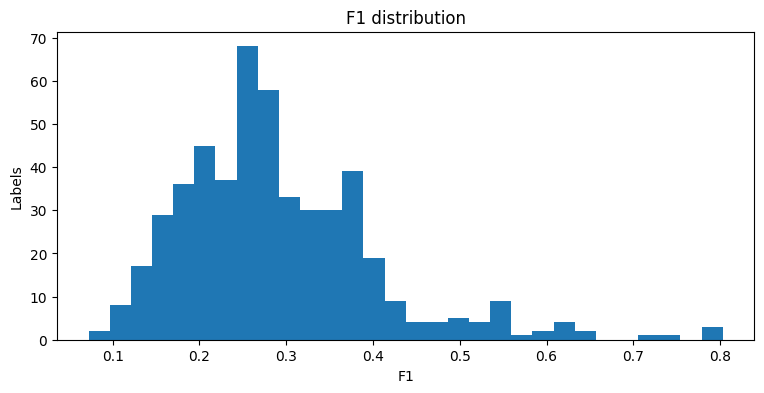

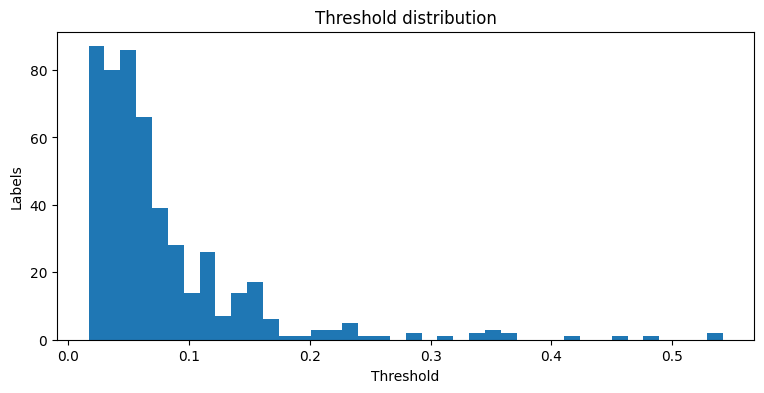

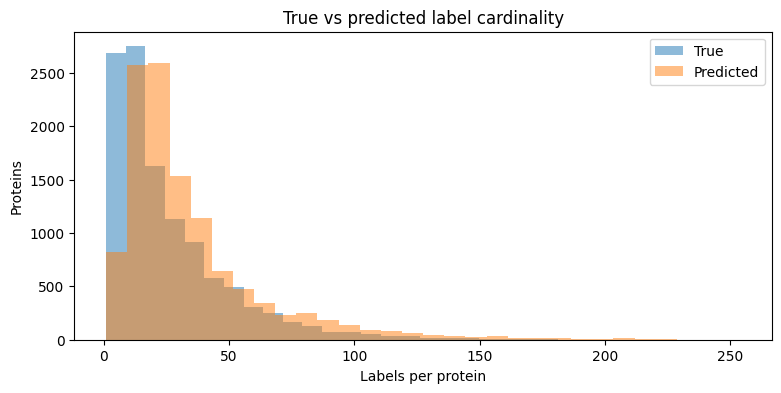

,label,train_positives,check_positives,predicted_positives,threshold,f1
467,label_467,1155,120,46,0.040996,0.072289
324,label_324,1799,226,105,0.038982,0.090634
473,label_473,1129,131,102,0.021821,0.103004
472,label_472,1121,138,132,0.022525,0.103704
461,label_461,1138,148,86,0.029539,0.111111
379,label_379,1531,176,549,0.022993,0.113103
478,label_478,1109,152,40,0.031477,0.114583
394,label_394,1466,172,384,0.023237,0.115108
367,label_367,1593,182,558,0.023727,0.118919
369,label_369,1589,182,529,0.023842,0.120956


In [29]:
diagnostics = pd.DataFrame({
    "label": TARGET_COLUMNS,
    "train_positives": Y_train.sum(axis=0),
    "check_positives": Y_check.sum(axis=0),
    "predicted_positives": check_predictions.sum(axis=0),
    "threshold": thresholds,
    "f1": f1_per_label,
})

mask = diagnostics["check_positives"] > 0
plt.figure(figsize=(9, 5))
plt.scatter(diagnostics.loc[mask, "check_positives"], diagnostics.loc[mask, "f1"], alpha=.45)
plt.xscale("log")
plt.xlabel("Positive examples in check")
plt.ylabel("F1")
plt.title("Label frequency vs F1")
plt.grid(alpha=.2)
plt.show()

plt.figure(figsize=(9, 4))
plt.hist(f1_per_label[active_labels], bins=30)
plt.xlabel("F1")
plt.ylabel("Labels")
plt.title("F1 distribution")
plt.show()

plt.figure(figsize=(9, 4))
plt.hist(thresholds, bins=40)
plt.xlabel("Threshold")
plt.ylabel("Labels")
plt.title("Threshold distribution")
plt.show()

plt.figure(figsize=(9, 4))
plt.hist(Y_check.sum(axis=1), bins=30, alpha=.5, label="True")
plt.hist(check_predictions.sum(axis=1), bins=30, alpha=.5, label="Predicted")
plt.xlabel("Labels per protein")
plt.ylabel("Proteins")
plt.title("True vs predicted label cardinality")
plt.legend()
plt.show()

display(diagnostics[mask].sort_values("f1").head(20))

## 8. Save experiment
Путь можно заменить на Google Drive. Конфигурация и честные метрики сохраняются вместе с моделью.

In [21]:
SAVE_ROOT = Path("./drive/MyDrive/results")
SAVE_DIR = SAVE_ROOT / EXPERIMENT_NAME
SAVE_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(vectorizer, SAVE_DIR / "vectorizer.joblib", compress=3)
joblib.dump(multi_model, SAVE_DIR / "multi_model.joblib", compress=3)
np.save(SAVE_DIR / "thresholds.npy", thresholds)
np.save(SAVE_DIR / "train_indices.npy", train_idx)
np.save(SAVE_DIR / "validation_indices.npy", val_idx)

run_info = {
    "ngram_range": list(NGRAM_RANGE),
    "min_df": MIN_DF,
    "sublinear_tf": SUBLINEAR_TF,
    "alpha": ALPHA,
    "class_weight": CLASS_WEIGHT,
    **metrics,
}
with open(SAVE_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(run_info, f, ensure_ascii=False, indent=2)

print("Saved to:", SAVE_DIR)

Saved to: drive/MyDrive/results/tfidf_4_5_sublinear_alpha1e6


## 9. Build submission
Используем те же vectorizer, model и thresholds, которые были оценены выше.

In [22]:
X_test = vectorizer.transform(test["sequence"])

test_probabilities = multi_model.predict_proba(
    X_test
).astype(np.float32)

# Используем 500 порогов текущей модели
assert honest_thresholds.shape == (N_LABELS,), (
    f"Expected {N_LABELS} thresholds, "
    f"got {honest_thresholds.shape}"
)

assert test_probabilities.shape[1] == N_LABELS

test_predictions = (
    test_probabilities >= honest_thresholds[None, :]
).astype(np.uint8)

# Создаём submission
submission = pd.DataFrame(
    test_predictions,
    columns=TARGET_COLUMNS
)

submission.insert(
    0,
    "protein_id",
    test["protein_id"].to_numpy()
)

# Проверки
assert submission.shape == (
    len(test),
    N_LABELS + 1
)

assert not submission.isna().any().any()

assert np.array_equal(
    submission["protein_id"].to_numpy(),
    test["protein_id"].to_numpy()
)

# Полезная диагностика
print("X_test:", X_test.shape)
print("Probabilities:", test_probabilities.shape)
print("Thresholds:", honest_thresholds.shape)

print(
    "Predicted labels/protein:",
    test_predictions.sum(axis=1).mean()
)

# Сохраняем
SUBMISSION_PATH = Path(
    f"./drive/MyDrive/results/submission_{EXPERIMENT_NAME}.csv"
)

submission.to_csv(
    SUBMISSION_PATH,
    index=False
)

print(
    "Saved:",
    SUBMISSION_PATH,
    submission.shape
)

display(submission.head())

X_test: (28450, 2851227)
Probabilities: (28450, 500)
Thresholds: (500,)
Predicted labels/protein: 27.535887521968366
Saved: drive/MyDrive/results/submission_tfidf_4_5_sublinear_alpha1e6.csv (28450, 501)


,protein_id,label_0,label_1,label_2,label_3,label_4,label_5,label_6,label_7,label_8,...,label_490,label_491,label_492,label_493,label_494,label_495,label_496,label_497,label_498,label_499
0,P112734,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,P112735,1,1,1,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,P112736,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,P112737,1,1,1,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,1
4,P112738,1,0,1,0,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


## Следующие эксперименты
Меняйте **по одному фактору за раз** в конфигурационной ячейке и сравнивайте `macro_f1` вместе с `macro_ap`, precision/recall и диагностическими графиками. Ближайшие варианты: `(3, 4)`, `sublinear_tf=True`, затем подбор `alpha`.